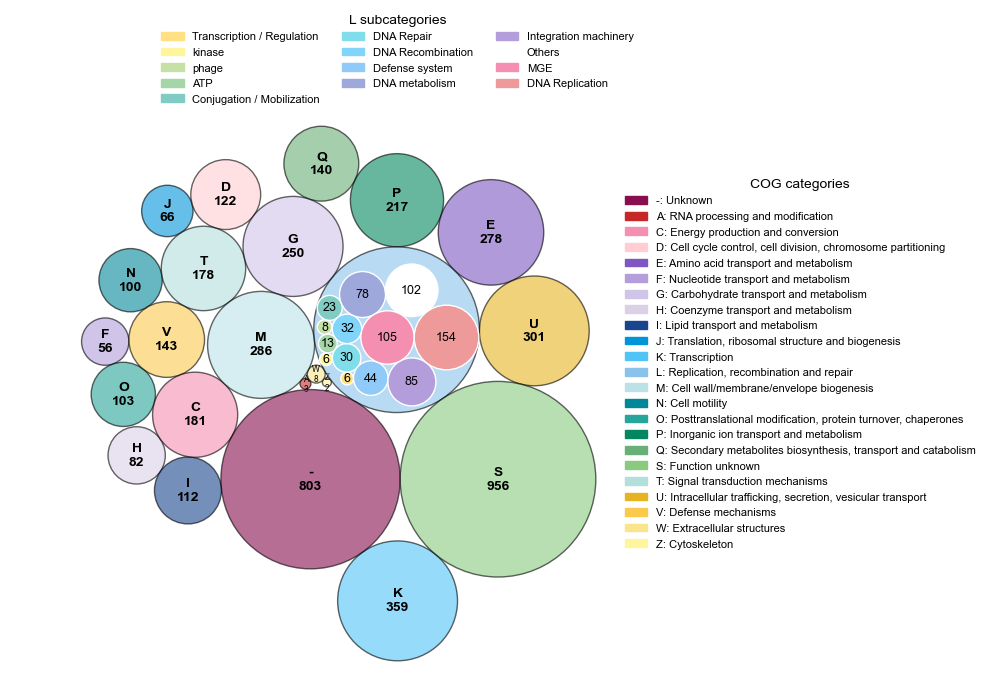

In [2]:
import pandas as pd
import circlify
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

# =========================
# 1. 读取数据
# =========================
input_file = "all_spacer_blast_short_result_phage_plasmid_gname_plasmid_only_ref_plasmid_target_gene_emapper_COG.txt"

df = pd.read_csv(input_file, header=None, names=["label", "value"])

df["label"] = df["label"].astype(str).str.strip()
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna()

df = df.sort_values(by="value", ascending=True).reset_index(drop=True)

labels = df["label"].tolist()
sizes = df["value"].tolist()

# =========================
# 2. 外层 circlify
# =========================
circles = circlify.circlify(
    sizes,
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1)
)

# =========================
# 3. COG 注释
# =========================
cog_map = {
"A":"RNA processing and modification",
"B":"Chromatin structure and dynamics",
"C":"Energy production and conversion",
"D":"Cell cycle control, cell division, chromosome partitioning",
"E":"Amino acid transport and metabolism",
"F":"Nucleotide transport and metabolism",
"G":"Carbohydrate transport and metabolism",
"H":"Coenzyme transport and metabolism",
"I":"Lipid transport and metabolism",
"J":"Translation, ribosomal structure and biogenesis",
"K":"Transcription",
"L":"Replication, recombination and repair",
"M":"Cell wall/membrane/envelope biogenesis",
"N":"Cell motility",
"O":"Posttranslational modification, protein turnover, chaperones",
"P":"Inorganic ion transport and metabolism",
"Q":"Secondary metabolites biosynthesis, transport and catabolism",
"S":"Function unknown",
"T":"Signal transduction mechanisms",
"U":"Intracellular trafficking, secretion, vesicular transport",
"V":"Defense mechanisms",
"W":"Extracellular structures",
"Z":"Cytoskeleton"
}

# =========================
# 4. 颜色
# =========================
unique_labels = sorted(set(labels))

color_strip = [
    "#880e4f","#c62828","#f48fb1","#ffcdd2","#7e57c2",
    "#b39ddb","#d1c4e9","#dbd0e6","#19448e","#0095d9","#50c3f7",
    "#89c3eb","#bce2e8","#008899","#26a69a","#028760","#69b076",
    "#88cb7f","#b2dfdb","#e6b422","#fbca4d","#f8e58c","#fff59d"
]

color_map = dict(zip(unique_labels, color_strip[:len(unique_labels)]))

# =========================
# 5. 字体
# =========================
rcParams.update({
    "font.family": "Arial"
})

# =========================
# 6. 画外层圆
# =========================
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')
ax.set_aspect('equal')

for i, circle in enumerate(circles):
    x, y, r = circle.x, circle.y, circle.r
    label = labels[i]
    size = sizes[i]

    ax.add_patch(plt.Circle(
        (x, y), r,
        facecolor=color_map[label],
        edgecolor="black",
        alpha=0.6
    ))

    if r > 0.06:
        ax.text(x, y, f"{label}\n{int(size)}",
                ha='center', va='center', fontsize=10, weight='bold',zorder=1)
    else:
        ax.text(x, y, f"{label}\n{int(size)}",
                ha='center', va='center', fontsize=6,zorder=1)#, weight='bold')

# =========================
# 7. 提取 L 圆
# =========================
L_index = labels.index("L")
L_circle = circles[L_index]

L_x, L_y, L_r = L_circle.x, L_circle.y, L_circle.r

# =========================
# 8. L 内数据（绑定 label + value）
# =========================
L_sub = {
    "DNA Replication": 154,
    "DNA metabolism": 78,
    "DNA Repair": 30,
    "DNA Recombination": 32,
    "Transcription / Regulation": 6,
    "ATP": 13,
    "kinase": 6,
    "Conjugation / Mobilization": 23,
    "Integration machinery": 85,
    "MGE": 105,
    "phage": 8,
    "Defense system": 44,
    "Others": 102
}

# ✅ 关键：绑定 + 排序
sub_data = [{"label": k, "value": v} for k, v in L_sub.items()]
sub_data = sorted(sub_data, key=lambda x: x["value"])

sub_values = [d["value"] for d in sub_data]

# =========================
# 9. L 内 circlify
# =========================
sub_circles = circlify.circlify(
    sub_values,
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1)
)

# =========================
# 10. 绘制 L 内小圆
# =========================
# color_strip1 = [
#     "#EF9A9A","#F48FB1","#CE93D8","#B39DDB","#9FA8DA",
#     "#90CAF9","#81D4FA","#80DEEA","#80CBC4","#A5D6A7","#C5E1A5",
#     "#FFF59D","#FFE082","#008899","#26a69a","#028760","#69b076"
# ]
color_strip1 = [
    "#EF9A9A","#F48FB1","white","#B39DDB","#9FA8DA",
    "#90CAF9","#81D4FA","#80DEEA","#80CBC4","#A5D6A7","#C5E1A5",
    "#FFF59D","#FFE082"][::-1]
for i, circle in enumerate(sub_circles):
    x, y, r = circle.x, circle.y, circle.r

    x_final = x * L_r + L_x
    y_final = y * L_r + L_y
    r_final = r * L_r

    label = sub_data[i]["label"]
    value = sub_data[i]["value"]

    ax.add_patch(plt.Circle(
        (x_final, y_final),
        r_final,
        facecolor=color_strip1[i % len(color_strip1)],
        edgecolor="white",
        linewidth=1
    ))

    # ✅ 显示数量（你要求的）
    ax.text(
        x_final,
        y_final,
        str(value),
        ha='center',
        va='center',
        fontsize=9,zorder=10
    )

# =========================
# 11. COG legend
# =========================
handles = [
    mpatches.Patch(color=color_map[k],
                   label=f"{k}: {cog_map.get(k, 'Unknown')}")
    for k in unique_labels
]

legend1 = plt.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(0.78, 0.5),
    fontsize=8,
    title="COG categories",
    frameon=False
)
ax.add_artist(legend1)

# =========================
# 12. L sub legend
# =========================
sub_handles = [
    mpatches.Patch(color=color_strip1[i % len(color_strip1)],
                   label=sub_data[i]["label"])
    for i in range(len(sub_data))
]

plt.legend(
    handles=sub_handles,
    title="L subcategories",
    loc="center",
    bbox_to_anchor=(0.5, 1),
    ncol=3,
    fontsize=8,
    frameon=False
)

# =========================
# 13. 保存
# =========================
ax.set_xlim(-1.2, 1.6)
ax.set_ylim(-1, 1.2)

# plt.savefig("COG_circle_packing_nested_20260505.png", dpi=800, bbox_inches='tight', pad_inches=0.3)
# plt.savefig("COG_circle_packing_nested_20260505.pdf", bbox_inches='tight')

plt.show()

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import gseapy as gp
from gseapy.plot import barplot, dotplot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
from matplotlib import rcParams
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['axes.unicode_minus']=False

In [6]:
custom_gradient = LinearSegmentedColormap.from_list("custom_gradient", ["#e2eef6", "#01579B"])
with open("all_spacer_target_plasmid_all_gene_emapper_r_fin_fin.txt") as f:
    COG_gene={}
    for i in f:
        i=i.strip().split("\t")
        if i[1] not in COG_gene.keys():
            COG_gene[i[1]]=[i[0]]
        else:
            COG_gene[i[1]].append(i[0])
    # for m,n in COG_gene.items():
    #     if m=="Z":
    #         print(m,n)
    #         break

In [7]:
gene_list="./all_spacer_target_plasmid_target_gene_emapper_r_gene_id.txt"
enr_go = gp.enrichr(gene_list=gene_list,#所需查询gene_list，可以是一个列表，也可为文件（一列，每行一个基因）
                 gene_sets=COG_gene,#gene set library，多个相关的gene set 。如所有GO term组成一个gene set library.
#                  organism='Human',#持(human, mouse, yeast, fly, fish, worm)， 自定义gene_set 则无影响。
#                  description='kegg',#工作运行描述
                 outdir='./enrichment_COG',#输出目录
                 top_term=1000,
                 cutoff=0.05#pvalue阈值
                 )

    Gene_set Term     Overlap       P-value  Adjusted P-value  Odds Ratio  \
69  gs_ind_0    U   203/17162  1.033859e-29      7.443784e-28    2.535279   
0   gs_ind_0    -  803/122857  8.275582e-19      2.979209e-17    1.424421   
10  gs_ind_0    D   115/11138  1.655185e-13      3.972444e-12    2.186998   
52  gs_ind_0    L  654/103807  2.379795e-12      4.283631e-11    1.353689   
71  gs_ind_0    V   140/15846  2.853770e-11      4.109429e-10    1.868138   
..       ...  ...         ...           ...               ...         ...   
39  gs_ind_0    I    83/23463  9.988912e-01      1.000000e+00    0.731802   
40  gs_ind_0   IQ    28/12386  9.999986e-01      1.000000e+00    0.472428   
42  gs_ind_0    J    57/15843  9.917544e-01      1.000000e+00    0.748000   
27  gs_ind_0    F    54/12706  8.434905e-01      1.000000e+00    0.886750   
35  gs_ind_0    H    64/19127  9.993012e-01      1.000000e+00    0.693582   

    Combined Score                                              Genes  \
69

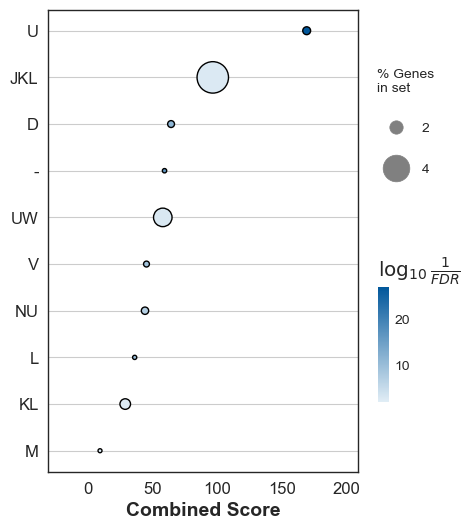

In [8]:
base_path='./enrichment_COG1'
sns.set_style("white")
res_sorted = enr_go.res2d.sort_values(by="Adjusted P-value", ascending=True)
res_sorted["logP"] = -np.log10(res_sorted["Adjusted P-value"])
print(res_sorted)
# print(res_sorted)
ax = dotplot(res_sorted,column="Adjusted P-value",x='Combined Score', cutoff=0.05, cmap=custom_gradient, size=80, figsize=(5,6))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.xaxis.label.set_size(14) ##标题
ax.yaxis.label.set_size(14)
for coll in ax.collections:
    coll.set_edgecolor("black")
    coll.set_linewidth(1)
# plt.savefig("enrichment_COG/COG_enrichment_dot_combine_0.05.png",bbox_inches = 'tight',dpi=600)
# ax.tick_params(axis='x', rotation=90)

{'replication', 'membrane', 'Conjugative', 'MGE', 'Others'}
       type_adj     dist_bin  bin_count
0   Conjugative       0-1000        735
1   Conjugative    1000-2000        296
2   Conjugative    2000-3000         93
3   Conjugative    3000-4000         49
4   Conjugative    4000-5000         50
..          ...          ...        ...
95  replication  15000-16000          2
96  replication  16000-17000          9
97  replication  17000-18000          2
98  replication  18000-19000          0
99  replication  19000-20000          0

[100 rows x 3 columns]
       type_adj     dist_bin  bin_count       density
0   Conjugative       0-1000        735  4.742001e-05
19  Conjugative  19000-20000          6  3.871021e-07
18  Conjugative  18000-19000          3  1.935510e-07
17  Conjugative  17000-18000          4  2.580681e-07
16  Conjugative  16000-17000          1  6.451702e-08
..          ...          ...        ...           ...
55       Others  15000-16000         16  1.421764e-08
56  

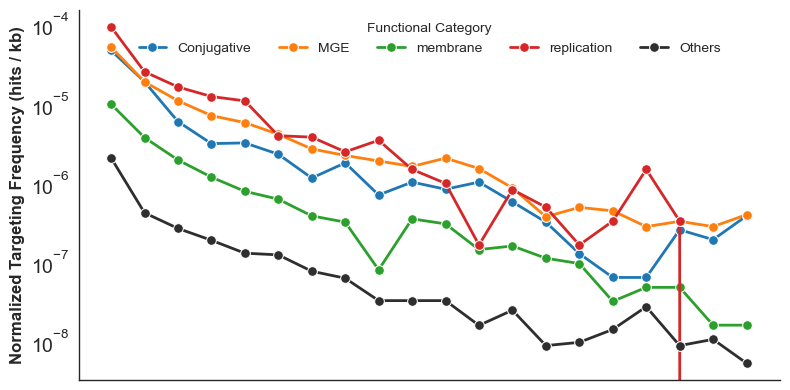

In [15]:
#####2026/4/15/####
####fin####
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# =========================
# 1. 参数与配置
# =========================
input_file = "all_spacer_target_5func_cefg_others_genelength_genomesize_distance_spacernum.txt"
gene_length="all_spacer_target_5func_cefg_gene_length.txt"
bin_size = 1000
max_dist = 20000
min_count_threshold = 3 

# 你关心的核心功能类别
target_types = ['Conjugative','MGE',  'membrane', 'replication',"Others"] # 请根据实际修改名称
core_types=['Conjugative','MGE',  'membrane', 'replication']
# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(input_file, sep="\t", header=None,
    names=["contig1","spacer_start","spacer_end","spacer",
           "genome_id","ref_contig","gene_start","gene_end",
           "ref_gene_id","type","gene_len","genome_sizes",
           "dist","count"])
# =========================
# 3. 数据清洗：统一分类标签
# =========================
df['dist'] = df['dist'].abs()
# 将所有不在核心列表里的命中（包括原本标为 Others 或无标签的）统一为 'Others'
df['type_adj'] = df['type'].apply(lambda x: x if x in core_types else 'Others')

# 每个 Spacer 对每种 type 只保留一个最近距离，消除重复计算
df_unique = df.loc[df.groupby(["spacer", "type_adj"])["dist"].idxmin()].copy()
print(set(list(df['type_adj'])))
# =========================
# 4. 构建全基因组背景 (减法逻辑计算 Expected)
# =========================
# 1. 计算核心四类蛋白的总长度（去重）
core_genes = pd.read_csv(gene_length, sep="\t", header=None,
    names=["type","fnc_gene_length"])
# core_genes = df[df['type'].isin(core_types)][['ref_gene_id', 'type', 'gene_len']].drop_duplicates()
core_type_lens = core_genes.groupby('type')['fnc_gene_length'].sum()
# 核心四类蛋白的总长度
core_total_len4 = core_type_lens[core_type_lens.index.isin(core_types)].sum()
# 2. 计算所有质粒的总物理长度
total_genome_size = df[['genome_id', 'genome_sizes']].drop_duplicates()['genome_sizes'].sum()
core_type_lens["Others"]=total_genome_size-core_total_len4
# =========================
# 3. 计算实际观测 (Observed Ratio)
# =========================
# 分箱
bins = np.arange(0, max_dist + bin_size, bin_size)
labels = [f"{i}-{i+bin_size}" for i in bins[:-1]]
df_unique['dist_bin'] = pd.cut(df_unique['dist'], bins=bins, labels=labels, right=False)

# 统计每类蛋白每个 Bin 里的命中数
obs = df_unique.groupby(['type_adj', 'dist_bin'], observed=False).size().reset_index(name='bin_count')
print(obs)
# 4. 标准化：Density = 数量 / 该类型的总长度 (kb)
obs['density'] = obs.apply(
    lambda x: x['bin_count'] / core_type_lens[x['type_adj']] if core_type_lens[x['type_adj']] > 0 else 0, 
    axis=1
)
# 强制按照 target_types 排序
obs['type_adj'] = pd.Categorical(obs['type_adj'], categories=target_types, ordered=True)
obs = obs.sort_values('type_adj')
counts=obs
print(counts)
# 6. 设置绘图风格与颜色
plt.figure(figsize=(8, 4))
sns.set_style("white")

# --- 关键修改：定义颜色映射字典 ---
# 前四个使用 Seaborn 默认调色板颜色，最后一个 "DEFG" 设为灰色
current_palette = sns.color_palette("tab10", len(target_types))
color_map = {
    "Conjugative": current_palette[0],
    "MGE": current_palette[1],
    "membrane": current_palette[2],
    "replication": current_palette[3],
    "CEFG": "#A0A0A0" , # 灰色
    "Others":"#2f2d2d"
}

# 7. 绘制折线图
sns.lineplot(
    data=counts, 
    x='dist_bin', 
    y='density', 
    hue='type_adj', 
    palette=color_map, # 应用自定义颜色
    marker='o', 
    linewidth=2,
    markersize=7
)

# 设置纵轴为对数坐标
plt.yscale('log')

# 8. 图形修饰
plt.xlabel('')
plt.ylabel('Normalized Targeting Frequency (hits / kb)', fontsize=12,fontweight='bold')
plt.xticks('',rotation=45, ha='right', fontsize=16) # 旋转角度稍微调小一点更美观
plt.yticks(fontsize=14)

# 设置图例位置与样式
plt.legend(title="Functional Category", bbox_to_anchor=(0.5, 1), loc='upper center', ncol=5,title_fontsize=10,  fontsize=10, frameon=False)

sns.despine() # 移除上方和右侧边框
plt.tight_layout()

# 9. 保存与显示
# mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig("20260513_distance_lineplot_normalize_kb_cefg.png", dpi=800, bbox_inches='tight')
# plt.savefig("20260513_distance_lineplot_normalize_kb_cefg.pdf")
plt.show()

--- Expected Ratios (Genome Occupancy) ---
type
CEFG           0.177087
Conjugative    0.012386
MGE            0.033912
membrane       0.049603
replication    0.004818
terminus       0.000063
Others         0.899281
Name: fnc_gene_length, dtype: float64


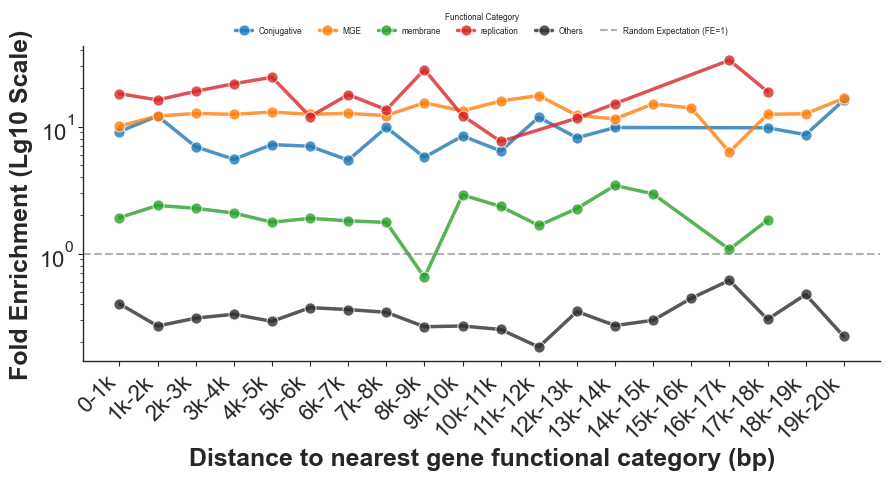


--- Statistics at 0-1k bp ---
       type_adj  fold_enrichment  bin_count
0   Conjugative         9.137905        735
20          MGE        10.094253       2223
60     membrane         1.918522        618
80  replication        18.184443        569
40       Others         0.402231       2349


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import warnings

# 忽略警告
warnings.filterwarnings("ignore", category=UserWarning)

# =========================
# 1. 参数与配置
# =========================
input_file = "all_spacer_target_5func_cefg_others_genelength_genomesize_distance_spacernum.txt"
gene_length = "all_spacer_target_5func_cefg_gene_length.txt"
bin_size = 1000
max_dist = 20000
min_count_threshold = 3 

# 核心功能类别
target_types = ['Conjugative', 'MGE', 'membrane', 'replication', 'Others']
core_types = ['Conjugative', 'MGE', 'membrane', 'replication']

# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(input_file, sep="\t", header=None,
                 names=["contig1","spacer_start","spacer_end","spacer",
                        "genome_id","ref_contig","gene_start","gene_end",
                        "ref_gene_id","type","gene_len","genome_sizes",
                        "dist","count"])

# =========================
# 3. 数据清洗
# =========================
df["type"] = df["type"].replace({"terminus": "replication"})
df['dist'] = df['dist'].abs()
# 统一分类
df['type_adj'] = df['type'].apply(lambda x: x if x in core_types else 'Others')

# 每个 Spacer 对每种类型只保留最近距离
df_unique = df.loc[df.groupby(["spacer", "type_adj"])["dist"].idxmin()].copy()

# =========================
# 4. 构建全基因组背景 (Expected)
# =========================
core_genes = pd.read_csv(gene_length, sep="\t", header=None, names=["type","fnc_gene_length"])
core_type_lens = core_genes.groupby('type')['fnc_gene_length'].sum()

# 计算质粒总长度
total_genome_size = df[['genome_id', 'genome_sizes']].drop_duplicates()['genome_sizes'].sum()

# 计算期望比例
expected_ratios = core_type_lens / total_genome_size
core_total_len4 = core_type_lens[core_type_lens.index.isin(core_types)].sum()
expected_ratios['Others'] = (total_genome_size - core_total_len4) / total_genome_size

print("--- Expected Ratios (Genome Occupancy) ---")
print(expected_ratios)

# =========================
# 5. 计算实际观测 (Observed Ratio) 并修改刻度标签
# =========================
bins = np.arange(0, max_dist + bin_size, bin_size)

# 生成 0-1k, 1k-2k 格式的标签
labels = []
for i in bins[:-1]:
    start_val = i
    end_val = i + bin_size
    
    # 格式化起始值
    start_str = f"{start_val//1000}k" if start_val >= 1000 else "0"
    # 格式化结束值
    end_str = f"{end_val//1000}k"
    
    labels.append(f"{start_str}-{end_str}")

df_unique['dist_bin'] = pd.cut(df_unique['dist'], bins=bins, labels=labels, right=False)

# 统计命中数
obs = df_unique.groupby(['type_adj', 'dist_bin'], observed=False).size().reset_index(name='bin_count')
bin_totals = obs.groupby('dist_bin')['bin_count'].transform('sum').astype(float)
obs['obs_ratio'] = np.where(bin_totals > 0, obs['bin_count'] / bin_totals, 0)

# =========================
# 6. 计算 Fold Enrichment (FE)
# =========================
obs['expected'] = obs['type_adj'].map(expected_ratios).astype(float)
obs['fold_enrichment'] = np.where(obs['expected'] > 0, obs['obs_ratio'] / obs['expected'], 0)

# 过滤低样本点
obs_plot = obs[obs['bin_count'] >= min_count_threshold].copy()
obs_plot['type_adj'] = pd.Categorical(obs_plot['type_adj'], categories=target_types, ordered=True)
obs_plot = obs_plot.sort_values(['type_adj', 'dist_bin'])

# =========================
# 7. 可视化
# =========================
sns.set_style("ticks")
current_palette = sns.color_palette("tab10", len(target_types))
color_map = {
    "Conjugative": current_palette[0],
    "MGE": current_palette[1],
    "membrane": current_palette[2],
    "replication": current_palette[3],
    "Others": "#2f2d2d"
}

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=obs_plot,
    x='dist_bin',
    y='fold_enrichment',
    hue='type_adj',
    hue_order=target_types,
    palette=color_map,
    marker='o',
    markersize=8,
    linewidth=2.5,
    alpha=0.8
)

# 绘制 FE=1 参考线
plt.axhline(1, linestyle='--', color='grey', alpha=0.6, label='Random Expectation (FE=1)')

# 对数轴处理
plt.yscale('log', base=10)

# 标签与字体设置
plt.xlabel("Distance to nearest gene functional category (bp)", fontsize=18, fontweight='bold')
plt.ylabel("Fold Enrichment (Lg10 Scale)", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)

# 图例设置
plt.legend(title='Functional Category', bbox_to_anchor=(0.5, 1.13), 
           loc='upper center', ncol=len(target_types)+1, title_fontsize=6, fontsize=6, frameon=False)

sns.despine()
plt.tight_layout()

# 保存设置
mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig("20260513_Final_Genome_Wide_FE_CEFG_others_genome_sizes.png", dpi=800)
# plt.savefig("20260513_Final_Genome_Wide_FE_CEFG_others_genome_sizes.pdf")
plt.show()

# 输出 0-1k 统计结果
print("\n--- Statistics at 0-1k bp ---")
print(obs_plot[obs_plot['dist_bin'] == labels[0]][['type_adj', 'fold_enrichment', 'bin_count']])